In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FactorAnalysis
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [2]:
# Dataset
df = pd.read_csv("winequality-red.csv", sep=";")
print(df.head)

<bound method NDFrame.head of       fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               7.4             0.700         0.00             1.9      0.076   
1               7.8             0.880         0.00             2.6      0.098   
2               7.8             0.760         0.04             2.3      0.092   
3              11.2             0.280         0.56             1.9      0.075   
4               7.4             0.700         0.00             1.9      0.076   
...             ...               ...          ...             ...        ...   
1594            6.2             0.600         0.08             2.0      0.090   
1595            5.9             0.550         0.10             2.2      0.062   
1596            6.3             0.510         0.13             2.3      0.076   
1597            5.9             0.645         0.12             2.0      0.075   
1598            6.0             0.310         0.47             3.6      0.067  

In [3]:
# Select imp features 

selected_features = [    
    "alcohol",
    "volatile acidity",
    "sulphates",
    "citric acid",
    "pH"
]

df_small = df[selected_features + ["quality"]]

df_small.head()

,alcohol,volatile acidity,sulphates,citric acid,pH,quality
0,9.4,0.70,0.56,0.00,3.51,5
1,9.8,0.88,0.68,0.00,3.20,5
2,9.8,0.76,0.65,0.04,3.26,5
3,9.8,0.28,0.58,0.56,3.16,6
4,9.4,0.70,0.56,0.00,3.51,5


In [4]:
# Target Values

X = df_small[[
    "alcohol",
    "volatile acidity",
    "sulphates",
    "citric acid",
    "pH" 
]]

y = df_small["quality"]

In [5]:
# Train-Test split

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
# Standardize

scaler = StandardScaler()
X_std = scaler.fit_transform(X)


# Correlation Martix
corr_matrix = pd.DataFrame(X_std, columns=X.columns).corr()

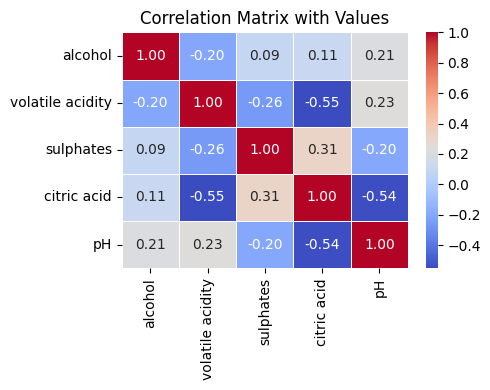

In [7]:
# Visualize Correlation Matrix

plt.figure(figsize=(5, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title("Correlation Matrix with Values")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [8]:
# Eigen Values

eigen_vals, eigen_vecs = np.linalg.eig(corr_matrix)
idx = np.argsort(eigen_vals)[::-1]
eigen_vals = eigen_vals[idx]
eigen_vecs = eigen_vecs[:, idx]

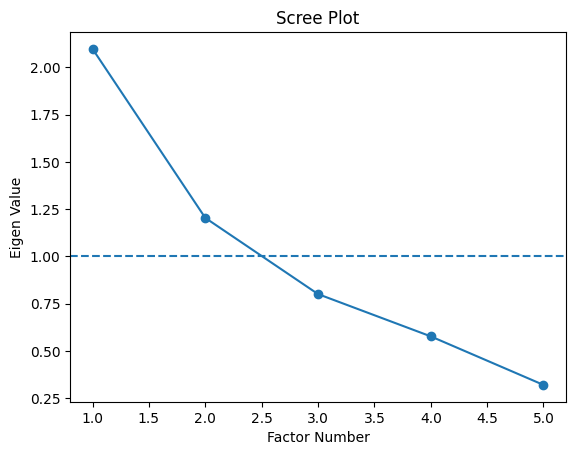

In [9]:
# Scree Plot

plt.figure()
plt.plot(range(1, len(eigen_vals)+1), eigen_vals, marker='o')
plt.axhline(1, linestyle='--')
plt.xlabel("Factor Number")
plt.ylabel("Eigen Value")
plt.title("Scree Plot")
plt.show()

In [10]:
# Number of Factors
n_factors = np.sum(eigen_vals > 1)
print("Factors Selected:", n_factors)

Factors Selected: 2


In [11]:
# Factor Analysis
fa = FactorAnalysis(n_components=n_factors, random_state=42)
X_factors = fa.fit_transform(X_std)

In [12]:
# Factor Loadings

factor_loadings = pd.DataFrame(
    fa.components_.T,
    columns=[f'Factor {i+1}' for i in range(n_factors)],
    index=X.columns
)

print("Factor Loadings")
display(factor_loadings)

Factor Loadings


,Factor 1,Factor 2
alcohol,0.029715,0.507693
volatile acidity,-0.570245,-0.382388
sulphates,0.348505,0.135296
citric acid,0.858776,0.162214
pH,-0.714195,0.443737


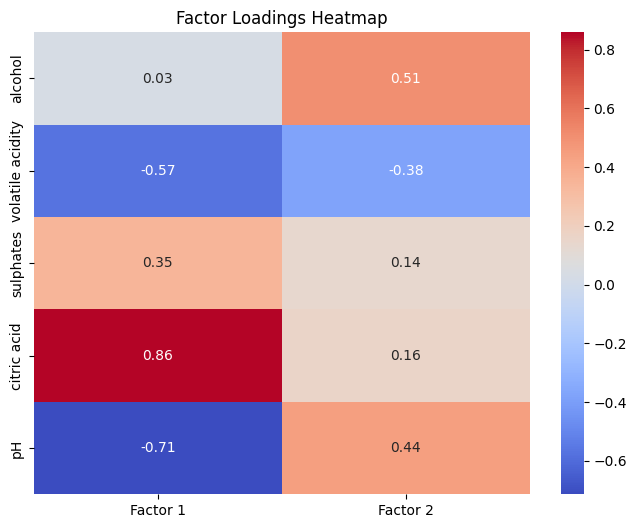

In [13]:
plt.figure(figsize=(8,6))

sns.heatmap(
    factor_loadings,
    annot=True,
    cmap="coolwarm"
)

plt.title("Factor Loadings Heatmap")
plt.show()